## Twitter Sentiment Analysis

In [61]:
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,LancasterStemmer
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from mlxtend.plotting import plot_confusion_matrix

## Importing the dataset

In [62]:
df = pd.read_csv(r"D:\Innomatics\Git_Uploads\twitter_sentiment_analysis\data\twitter_training.csv", header=None,
                 names=["tweet_id","entity","sentiment","tweet"])

In [63]:
df.head(5)

,tweet_id,entity,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [64]:
df.shape

(74682, 4)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [66]:
df.isnull().sum()

tweet_id       0
entity         0
sentiment      0
tweet        686
dtype: int64

In [67]:
df.dropna(subset="tweet",inplace=True)

In [68]:
df.isnull().sum()

tweet_id     0
entity       0
sentiment    0
tweet        0
dtype: int64

In [69]:
df["sentiment"].value_counts()

sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

In [70]:
df[df["sentiment"] == "Irrelevant"]

,tweet_id,entity,sentiment,tweet
102,2418,Borderlands,Irrelevant,Appreciate the (sonic) concepts / praxis Valen...
103,2418,Borderlands,Irrelevant,Appreciate the (sound) concepts / practices th...
104,2418,Borderlands,Irrelevant,Evaluate the (sound) concepts / concepts of Va...
105,2418,Borderlands,Irrelevant,Appreciate the (sonic) concepts / praxis Valen...
106,2418,Borderlands,Irrelevant,Appreciate by the ( sonic ) electronic concept...
...,...,...,...,...
74035,9085,Nvidia,Irrelevant,This is all based on last quarter's earnings. ...
74036,9085,Nvidia,Irrelevant,Let's see how well they handle the next one wh...
74037,9085,Nvidia,Irrelevant,Good on them. This stuff all based on earnings...
74038,9085,Nvidia,Irrelevant,9 Good idea for them. This is all based on ear...


In [71]:
## Dropping the Irrevelant sentiment data as its not needed for our sentiment analysis

In [72]:
df = df[df["sentiment"] != "Irrelevant"].reset_index(drop=True)

In [73]:
df["sentiment"].value_counts()

sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

In [74]:
df_copy = df.copy()

In [75]:
df.drop(axis=0,columns=["tweet_id","entity"],inplace= True)

In [76]:
## Assiging numbers for sentiment for faster computation

In [77]:
sentiment_num = {"Negative":0,"Neutral" : 1, "Positive":2}
df["sentiment"] = df["sentiment"].map(sentiment_num)
df["sentiment"].value_counts()

sentiment
0    22358
2    20655
1    18108
Name: count, dtype: int64

min_count = 7000
df = pd.concat([
    df[df["sentiment"] == 0].sample(min_count, random_state=42),
    df[df["sentiment"] == 1].sample(min_count, random_state=42),
    df[df["sentiment"] == 2].sample(min_count, random_state=42)
]).reset_index(drop=True)

In [78]:
df.shape

(61121, 2)

### Text Preprocessing

#### Testing

In [79]:
test = df["tweet"].sample().iloc[0]
test

'Disappearing from the face of the earth'

In [80]:
test = test.lower()

In [81]:
test = re.sub(r"http\S+|www\S+","",test) ## Removes Link
test = re.sub(r"@\w+|@+","",test) ## Removes Mentions
test = re.sub(r"<\S+","",test) ## Removes Tage
test = re.sub(r"\w\S+\.com\S+","",test) ## removes other .com text
test = re.sub(r"\w+\.\S+","",test)  ## removes site links
test =  re.sub(r"#","",test) ## Removes symbol
test

'disappearing from the face of the earth'

In [82]:
spec_char = r"[^a-z!?\s]"
test = re.sub(spec_char,"",test)

In [83]:
sw = stopwords.words("english")

In [84]:
n_sw = ['don', "don't", 'couldn', 'aren', "aren't", "not", "couldn't",
        'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn',
        "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan',
        "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren',
        "weren't", 'won', "won't", 'wouldn', "wouldn't"]

p_sw = set(sw).difference(n_sw)

In [85]:
print("Total stopwords: ",len(sw))
print("Negative stopwords: ",len(n_sw))
print("Positive Stoprods: ",len(p_sw))

Total stopwords:  198
Negative stopwords:  38
Positive Stoprods:  160


In [86]:
ps = PorterStemmer()
la = LancasterStemmer()

In [87]:
## Tokenization
test = test.split()

In [88]:
test = [ps.stem(word) for word in test if word not in p_sw]
test

['disappear', 'face', 'earth']

In [89]:
test= " ".join(test)

In [90]:
test

'disappear face earth'

In [91]:
## Text Preprocessing Funsction
def text_preprocessing(tweet):
    ## Lower Case
    tweet = tweet.lower()
    ## Removing tags and links
    tweet = re.sub(r"http\S+|www\S+","",tweet) ## Removes Link
    tweet = re.sub(r"@\w+|@+","",tweet) ## Removes Mentions
    tweet = re.sub(r"<\S+","",tweet) ## Removes Tage
    tweet = re.sub(r"\w\S+\.com\S+","",tweet) ## removes other .com text
    tweet = re.sub(r"\w+\.\S+","",tweet)  ## removes site links
    tweet =  re.sub(r"#","",tweet) ## Removes symbol
    ## Remove punctuations
    spec_char = r"[^a-z!?\s]"
    tweet = re.sub(spec_char,"",tweet)
    ## Tokenization
    tweet = tweet.split()
    ## Steming and Pos Stopwords removal
    tweet = [ps.stem(word) for word in tweet if word not in p_sw]
    tweet = " ".join(tweet)
    
    return tweet

In [92]:
df["tweet"] = df["tweet"].apply(text_preprocessing)

In [93]:
df.sample(5)

,sentiment,tweet
29562,2,year never tri ive work like miracl pixelsens ...
23102,1,take look new caustic heirloom
39226,0,not even finna cap shop home depot despis men
34302,2,pretti amaz stream time tonight pubg lot fun! ...
15734,1,feel like biggest weak warcraft commun guild g...


## Visualization

In [94]:
wc =WordCloud()

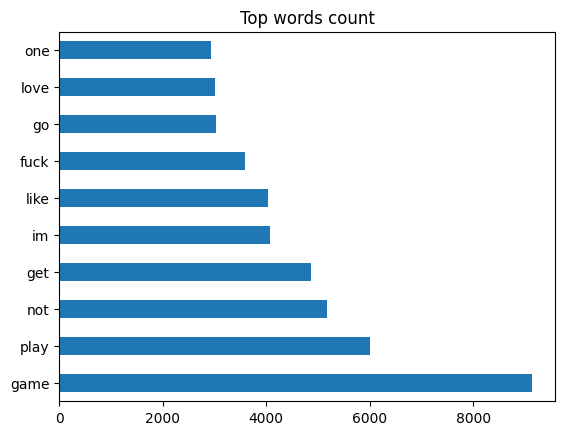

In [95]:
para = " ".join(df["tweet"])
words = pd.Series(para.split())
words.value_counts().head(10).plot(kind="barh")
plt.title("Top words count")
plt.show()

In [96]:
pos_para = " ".join(df[df["sentiment"] == 2 ]["tweet"])
neg_para = " ".join(df[df["sentiment"] == 0 ]["tweet"])
neutral_para = " ".join(df[df["sentiment"] == 1 ]["tweet"])

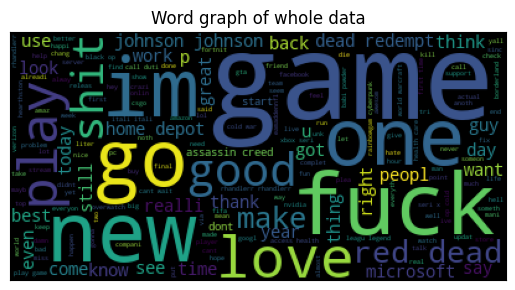

In [97]:
para_wc = wc.generate(para)
plt.imshow(para_wc)
plt.xticks([])
plt.yticks([])
plt.title("Word graph of whole data")
plt.show()

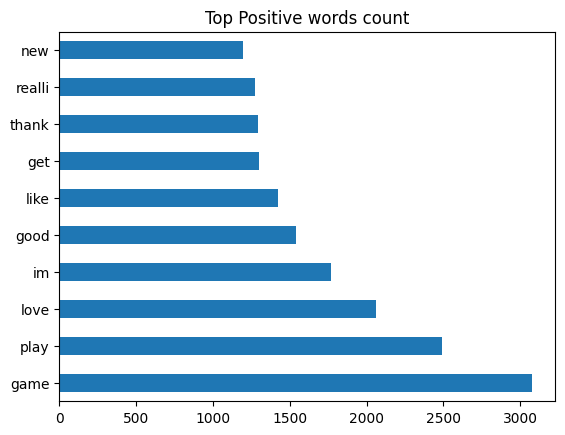

In [98]:
pos_words = pd.Series(pos_para.split())
pos_words.value_counts().head(10).plot(kind="barh")
plt.title("Top Positive words count")
plt.show()

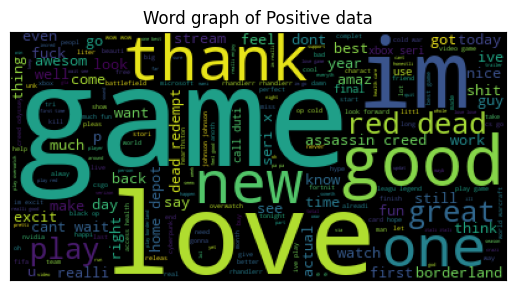

In [99]:
pos_para_wc = wc.generate(pos_para)
plt.imshow(pos_para_wc)
plt.xticks([])
plt.yticks([])
plt.title("Word graph of Positive data")
plt.show()

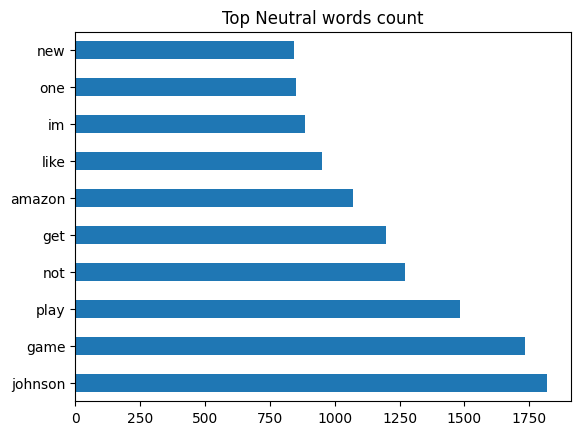

In [100]:
neutral_words = pd.Series(neutral_para.split())
neutral_words.value_counts().head(10).plot(kind="barh")
plt.title("Top Neutral words count")
plt.show()

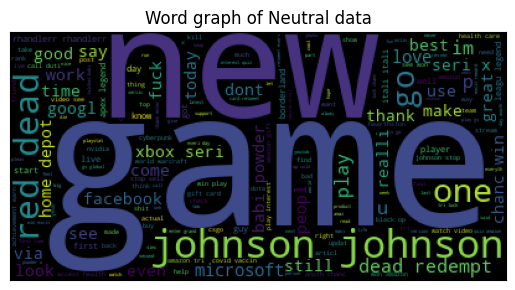

In [101]:
neutral_para_wc = wc.generate(neutral_para)
plt.imshow(neutral_para_wc)
plt.xticks([])
plt.yticks([])
plt.title("Word graph of Neutral data")
plt.show()

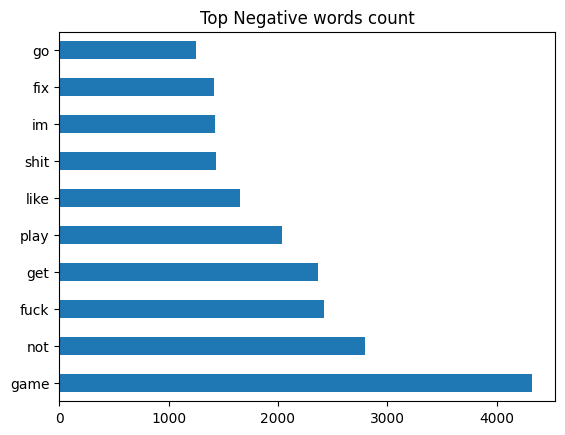

In [102]:
neg_words = pd.Series(neg_para.split())
neg_words.value_counts().head(10).plot(kind="barh")
plt.title("Top Negative words count")
plt.show()

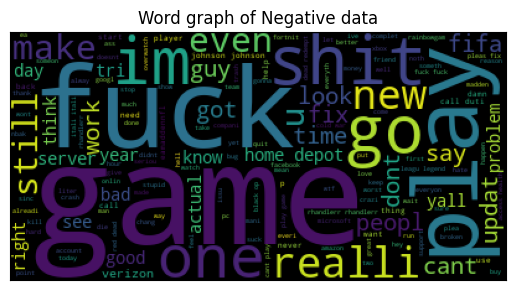

In [103]:
neg_para_wc = wc.generate(neg_para)
plt.imshow(neg_para_wc)
plt.xticks([])
plt.yticks([])
plt.title("Word graph of Negative data")
plt.show()

## Vectorization

### TF-IDF

In [117]:
tfidf = TfidfVectorizer(max_features=20000,ngram_range=(1,2))

In [118]:
X = tfidf.fit_transform(df["tweet"])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 720214 stored elements and shape (61121, 20000)>

In [119]:
cols = tfidf.get_feature_names_out()

In [120]:
# X = pd.DataFrame(X,columns=cols)

In [121]:
y = df["sentiment"]

## Train and Test Split

In [122]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [123]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((48896, 20000), (12225, 20000), (48896,), (12225,))

## Scaling

In [124]:
sc = MinMaxScaler()

In [141]:
## Scaling has been skipped to avoid memory overload and the switch the model to MultinomialNB to handle sparse data without array

In [142]:
## X_train = sc.fit_transform(X_train.toarray())
## X_test = sc.transform(X_test.toarray())

## Building Model

In [125]:
nb_model = MultinomialNB()

In [126]:
nb_model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Prediction

In [127]:
y_pred_train = nb_model.predict(X_train)
y_pred_test = nb_model.predict(X_test)

## Evaluation

In [128]:
train_acc = accuracy_score(y_train,y_pred_train)
test_acc = accuracy_score(y_test,y_pred_test)

print("Train accuracy -- ",train_acc)
print("Test accuracy -- ",test_acc)

Train accuracy --  0.8326243455497382
Test accuracy --  0.7914110429447853


In [129]:
print(classification_report(y_test, y_pred_test, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.75      0.89      0.81      4427
     Neutral       0.85      0.65      0.74      3678
    Positive       0.80      0.81      0.81      4120

    accuracy                           0.79     12225
   macro avg       0.80      0.78      0.79     12225
weighted avg       0.80      0.79      0.79     12225



In [131]:
cm_train = confusion_matrix(y_train,y_pred_train)
cm_test = confusion_matrix(y_test,y_pred_test)

In [132]:
from mlxtend.plotting import plot_confusion_matrix

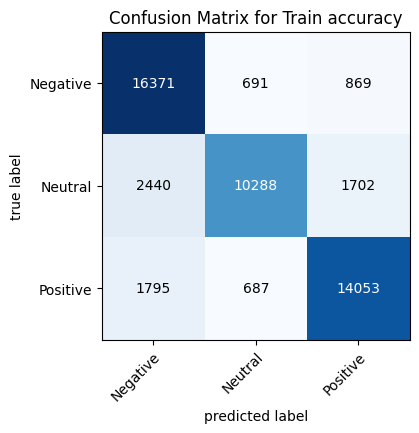

In [140]:
fig,ax = plot_confusion_matrix(cm_train,class_names=["Negative","Neutral","Positive"],figsize=(4,4))
plt.title("Confusion Matrix for Train accuracy")
plt.show()

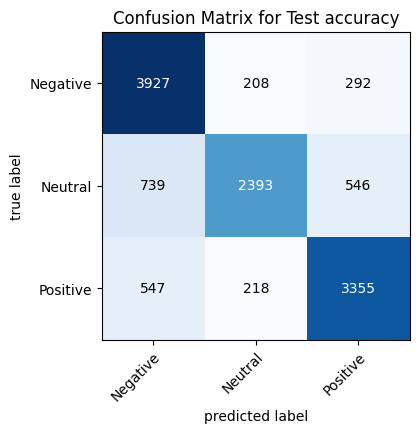

In [139]:
fig,ax = plot_confusion_matrix(cm_test,class_names=["Negative","Neutral","Positive"],figsize=(4,4))
plt.title("Confusion Matrix for Test accuracy")
plt.show()

## Real Time Prediction

In [168]:
def realtimeprediction(new_tweet):
    new_tweet = text_preprocessing(new_tweet)
    new_tweet = tfidf.transform([new_tweet]).toarray()
    pred = nb_model.predict(new_tweet) ## MultinomialNB can handle un-scaled data
    classes = ["Neagtive","Neutral","Positive"]
    
    return classes[pred[0]]
    

In [178]:
new_tweet = "Traffic is currently diverted on Main Street due to scheduled road maintenance. Seek alternate routes."

In [179]:
realtimeprediction(new_tweet)

'Neutral'

## Batch Testing

In [217]:
def batch_testing(tweets_list):
    success = 0
    Failed = 0
    for i in tweets_list:
        tweet = i["text"]
        senti = i["sentiment"] 
        pred = realtimeprediction(tweet)
        print(f"\n Tweet : {tweet}")
        print("Predicted --",pred,", Actual --",senti)
        
        if pred.lower() == senti.lower():
            success += 1
        else:
            Failed += 1
    return (f"Success = {success} , Failed = {Failed}")

In [218]:
extreme_tweets = [
    # Extreme Negative
    {"text": "Absolutely gutted. This earnings report is a complete disaster. Management lied to our faces and the stock is totally worthless now.", "sentiment": "negative"},
    {"text": "Worst customer service experience of my entire life. I’ve been overcharged by $500, and these thieving scammers refuse to refund me!", "sentiment": "negative"},
    {"text": "Total scam! Do not buy this garbage software. It crashed my entire system, wiped my database, and the devs are completely ignoring the issue.", "sentiment": "negative"},
    {"text": "I am officially bankrupt because of this market crash. Everything is gone. There is zero hope left for this absolute dumpster fire of an economy.", "sentiment": "negative"},
    {"text": "Disgusting and pathetic. The CEO should be in prison for this level of gross negligence and fraud. Never touching this toxic company again.", "sentiment": "negative"},
    {"text": "My flight was canceled, my luggage is destroyed, and the airline staff literally laughed at me. Absolute trash tier service. Rot in hell.", "sentiment": "negative"},
    {"text": "This is the most abysmal, broken, and useless piece of hardware I've ever had the misfortune of buying. Straight into the garbage where it belongs.", "sentiment": "negative"},

    # Extreme Neutral
    {"text": "The SPX index closed at 4,123.50 today, representing a 0.00% change from the previous trading session.", "sentiment": "neutral"},
    {"text": "Company ABC has scheduled its Q3 earnings call for Thursday, October 15th at 8:30 AM Eastern Time.", "sentiment": "neutral"},
    {"text": "The atmospheric pressure is currently reading 1013 hPa with a relative humidity of 45%.", "sentiment": "neutral"},
    {"text": "Section 4, Paragraph 2 of the updated terms of service outlines the revised data retention policy spanning 30 to 90 days.", "sentiment": "neutral"},
    {"text": "Water boils at 100 degrees Celsius at sea level under standard atmospheric conditions.", "sentiment": "neutral"},
    {"text": "The SQL query executed in 1.4 seconds, returning 54,231 rows from the primary database cluster.", "sentiment": "neutral"},
    {"text": "The central bank announced a 25 basis point adjustment to the target interest rate, effective immediately.", "sentiment": "neutral"},

    # Extreme Positive
    {"text": "This is undeniably the greatest financial quarter in the history of the company! Phenomenal growth, absolutely flawless execution!", "sentiment": "positive"},
    {"text": "I am literally crying tears of joy! I just got accepted into my dream program and my entire life is changing for the better! BEST DAY EVER! 🎉", "sentiment": "positive"},
    {"text": "Flawless! Perfect! Magnificent! This new update completely revolutionized my workflow and saved me hundreds of hours. Pure genius!", "sentiment": "positive"},
    {"text": "Absolutely phenomenal service! The team went infinitely above and beyond to secure the best possible outcome. I will recommend them to literally everyone on Earth!", "sentiment": "positive"},
    {"text": "We just hit an all-time high! The momentum is absolutely unstoppable right now. We are going straight to the moon! 🚀🚀🚀", "sentiment": "positive"},
    {"text": "The most delicious, life-altering meal I have ever experienced. Every single bite was pure, unadulterated perfection. A true masterpiece.", "sentiment": "positive"},
    {"text": "I am vibrating with excitement! The project launched without a single bug, metrics are through the roof, and the client is ecstatic. Absolute massive win!", "sentiment": "positive"}
]

In [219]:
batch_testing(extreme_tweets)


 Tweet : Absolutely gutted. This earnings report is a complete disaster. Management lied to our faces and the stock is totally worthless now.
Predicted -- Neagtive , Actual -- negative

 Tweet : Worst customer service experience of my entire life. I’ve been overcharged by $500, and these thieving scammers refuse to refund me!
Predicted -- Neagtive , Actual -- negative

 Tweet : Total scam! Do not buy this garbage software. It crashed my entire system, wiped my database, and the devs are completely ignoring the issue.
Predicted -- Neagtive , Actual -- negative

 Tweet : I am officially bankrupt because of this market crash. Everything is gone. There is zero hope left for this absolute dumpster fire of an economy.
Predicted -- Neagtive , Actual -- negative

 Tweet : Disgusting and pathetic. The CEO should be in prison for this level of gross negligence and fraud. Never touching this toxic company again.
Predicted -- Neagtive , Actual -- negative

 Tweet : My flight was canceled, my lugg

'Success = 12 , Failed = 9'

## Save the model

In [220]:
import joblib

In [221]:
nb_model.tfidf = tfidf

In [222]:
joblib.dump(nb_model,"Twitter_Sentiemnt_Analysis_TfIdf.pkl")

['Twitter_Sentiemnt_Analysis_TfIdf.pkl']